# Machine Learning Para Predição de Desempenho de Alunos do 3º/4º do Ensino Médio

## Integrantes
- Ana Caroline Souza Lira
- Daniel Goulart Camacho Gonçalves
- Fernando Giongo
- Theo Luigi
- João Gabriel Lourenço Marques

---
O projeto tem por objetivo prever os níveis Saeb de proficiência em Lingua Portuguesa (LP) ou Matemática (MT) de alunos do 3º e 4º Anos do Ensino Médio. Para isso, utilizaremos classificadores de Aprendizado de Máquina em cima dos microdados do Saeb de 2023 e a biblioteca Pandas do Python.

# Pré-processamento de dados

Primeiramente importamos todas as bibliotecas necessárias e lemos dos arquivos csv as informações das tabelas "TS_ALUNO_34EM", "TS_DIRETOR", "TS_ESCOLA".

In [111]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_aluno_original = pd.read_csv('dados/TS_ALUNO_34EM.csv', encoding='latin-1', sep=';')
df_diretor_original = pd.read_csv('dados/TS_DIRETOR.csv', encoding='latin-1', sep=';')
df_escola_original = pd.read_csv('dados/TS_ESCOLA.csv', encoding='latin-1', sep=';')

O próximo passo será definir quais features serão mantidas para análise. Para preservar o escopo do estudo, investigamos o dicionário de dados em busca de variáveis que representassem o contexto socioeconômico familiar, a infraestrutura física das escolas e a capacitação dos professores. Esses fatores foram selecionados primariamente por serem aspectos que, em tese, apresentam grande potencial de influência sobre o desempenho dos alunos. Ao longo do projeto, avaliaremos o comportamento dessas variáveis e sua efetiva relevância com os modelos desenvolvidos.

Nesse momento, também definimos critérios de limpeza dos dados. No conjunto de alunos, foram removidos os registros de estudantes que não compareceram às provas ou que responderam pelo menos três questões do questionário socioeconômico. De forma semelhante, no conjunto de diretores, excluímos os registros daqueles que não preencheram o questionário ou que não eram responsáveis por alunos do 3º ou o 4º ano do Ensino Médio. Por fim, no conjunto de escolas, foram removidas as instituições que não possuíam alunos matriculados nessas séries.

In [112]:
# ================================================================
# Escolhemos a features que temos interesses e as features
# que usaremos para limpar linhas que não tenham dados relevantes
# ================================================================

colunas_de_interesse_aluno = ['ID_ESCOLA', 'ID_ALUNO', 'ID_UF', 'ID_MUNICIPIO', 'ID_AREA', 'IN_PUBLICA', 'ID_SERIE', 'PROFICIENCIA_LP_SAEB', 
'PROFICIENCIA_MT_SAEB', 'TX_RESP_Q01', 'TX_RESP_Q02', 'TX_RESP_Q03', 'TX_RESP_Q04', 'TX_RESP_Q05a', 'TX_RESP_Q05b',
'TX_RESP_Q05c', 'TX_RESP_Q06','TX_RESP_Q07a','TX_RESP_Q07b','TX_RESP_Q07c','TX_RESP_Q07d','TX_RESP_Q07e','TX_RESP_Q08','TX_RESP_Q09',
'TX_RESP_Q10a','TX_RESP_Q10b','TX_RESP_Q10c','TX_RESP_Q10d','TX_RESP_Q10e','TX_RESP_Q10f','TX_RESP_Q11a','TX_RESP_Q11b','TX_RESP_Q11c',
'TX_RESP_Q12b','TX_RESP_Q12c','TX_RESP_Q14','TX_RESP_Q15b','TX_RESP_Q16','TX_RESP_Q17','TX_RESP_Q18','TX_RESP_Q19','TX_RESP_Q21a',
'TX_RESP_Q21b','TX_RESP_Q21c','TX_RESP_Q21d','TX_RESP_Q21e','TX_RESP_Q23d','TX_RESP_Q24']

remover_aluno = {
    'IN_PRESENCA_LP': 0,                    # Remover alunos que não tenham respondido a prova de língua portuguesa
    'IN_PRESENCA_MT': 0,                    # Remover alunos que não tenham respondido a prova de matemática
    'IN_PROFICIENCIA_LP': 0,                # Remover alunos que não tenham proficiência em língua portuguesa
    'IN_PROFICIENCIA_MT': 0,                # Remover alunos que não tenham proficiência em matemática
    'IN_PREENCHIMENTO_QUESTIONARIO': 0}     # Remover alunos que não preencheram o questionário

colunas_de_interesse_diretor = ['ID_ESCOLA', 'ID_SERIE', 'TX_Q020','TX_Q022','TX_Q032','TX_Q033','TX_Q035',
'TX_Q036','TX_Q056','TX_Q057','TX_Q078','TX_Q079','TX_Q081','TX_Q082','TX_Q083', 'TX_Q085','TX_Q087',
'TX_Q108','TX_Q119','TX_Q129','TX_Q130','TX_Q139','TX_Q191','TX_Q194','TX_Q203','TX_Q205','TX_Q206','TX_Q207',
'TX_Q208','TX_Q209']

remover_diretor = {
    'IN_PREENCHIMENTO_QUESTIONARIO': [0],   # Remover diretores que não preencheram o questionário
    'ID_SERIE': [5, 9, 2]}

colunas_de_interesse_escola = ['ID_ESCOLA','PC_FORMACAO_DOCENTE_MEDIO', 'MEDIA_EM_LP','MEDIA_EM_MT']

remover_escola = {
    'NU_PRESENTES_EM': 0}                   # Remover escolas que não tenham alunos presentes no ensino médio


# ================================================================
# Aplicaremos as regras de limpeza de dados e selecionaremos as features
# ================================================================

print("\n# ================================================================\n")
df_aluno_limpo = df_aluno_original.copy()
df_diretor_limpo = df_diretor_original.copy()
df_escola_limpo = df_escola_original.copy()

for coluna, valor in remover_aluno.items():
    antes = len(df_aluno_limpo)
    df_aluno_limpo = df_aluno_limpo[df_aluno_limpo[coluna] != valor]
    removidas = antes - len(df_aluno_limpo)
    
    print(
        f"Alunos: removidas {removidas} linhas "
        f"pela regra: {coluna} != {valor}"
    )

for coluna, valor in remover_diretor.items():
    antes = len(df_diretor_limpo)
    df_diretor_limpo = df_diretor_limpo[~df_diretor_limpo[coluna].isin(valor)]
    removidas = antes - len(df_diretor_limpo)

    print(
        f"Diretores: removidas {removidas} linhas "
        f"pela regra: {valor} não estar em {coluna}"
    )

for coluna, valor in remover_escola.items():
    antes = len(df_escola_limpo)
    df_escola_limpo = df_escola_limpo[df_escola_limpo[coluna] != valor]
    removidas = antes - len(df_escola_limpo)

    print(
        f"Escolas: removidas {removidas} linhas "
        f"pela regra: {coluna} != {valor}"
    )

df_aluno_limpo = df_aluno_limpo[colunas_de_interesse_aluno]
df_diretor_limpo = df_diretor_limpo[colunas_de_interesse_diretor]
df_escola_limpo = df_escola_limpo[colunas_de_interesse_escola]

print("\n# ================================================================\n")
print(f'Alunos: {len(df_aluno_limpo)} linhas')
print(f'Diretores: {len(df_diretor_limpo)} linhas')
print(f'Escolas: {len(df_escola_limpo)} linhas')
print("\n# ================================================================\n")

# Quantidade de linhas removidas do dataset original
print(f'Alunos: {len(df_aluno_original) - len(df_aluno_limpo)} linhas removidas do dataset original -> {(len(df_aluno_limpo))/len(df_aluno_original)*100:.2f}% linhas restantes')
print(f'Diretores: {len(df_diretor_original) - len(df_diretor_limpo)} linhas removidas do dataset original -> {(len(df_diretor_limpo))/len(df_diretor_original)*100:.2f}% linhas restantes')
print(f'Escolas: {len(df_escola_original) - len(df_escola_limpo)} linhas removidas do dataset original -> {(len(df_escola_limpo))/len(df_escola_original)*100:.2f}% linhas restantes')

print("\n# ================================================================\n")


# ================================================================

Alunos: removidas 562414 linhas pela regra: IN_PRESENCA_LP != 0
Alunos: removidas 0 linhas pela regra: IN_PRESENCA_MT != 0
Alunos: removidas 2966 linhas pela regra: IN_PROFICIENCIA_LP != 0
Alunos: removidas 0 linhas pela regra: IN_PROFICIENCIA_MT != 0
Alunos: removidas 11509 linhas pela regra: IN_PREENCHIMENTO_QUESTIONARIO != 0
Diretores: removidas 17304 linhas pela regra: [0] não estar em IN_PREENCHIMENTO_QUESTIONARIO
Diretores: removidas 72208 linhas pela regra: [5, 9, 2] não estar em ID_SERIE
Escolas: removidas 122 linhas pela regra: NU_PRESENTES_EM != 0

# ================================================================

Alunos: 1514448 linhas
Diretores: 17577 linhas
Escolas: 70029 linhas

# ================================================================

Alunos: 576889 linhas removidas do dataset original -> 72.42% linhas restantes
Diretores: 89512 linhas removidas do dataset original -> 16.41% linhas restantes


In [113]:
# ================================================================
# Podemos ter problemas ao unificar as tabelas se houver escolas
# com o mesmo ID e multiplos diretores
# ================================================================

print("\n# ================================================================\n")
print(f"Alunos em mais de uma escola: {df_aluno_limpo['ID_ALUNO'].duplicated().sum()}")
print(f"Alunos duplicados: {df_aluno_limpo['ID_ALUNO'].duplicated().sum()}")


print(f"Escolas com ID_ESCOLA duplicados: {df_escola_limpo['ID_ESCOLA'].duplicated().sum()}")

escolas_com_diretores_duplicados = (
    df_diretor_limpo['ID_ESCOLA']
    .value_counts()
    .loc[lambda x: x > 1]
)

escolas_sem_diretores = (
    df_escola_limpo['ID_ESCOLA']
    .loc[~df_escola_limpo['ID_ESCOLA'].isin(df_diretor_limpo['ID_ESCOLA'])]
)

print(f'Escolas com mais de um diretor: {len(escolas_com_diretores_duplicados)}')
print("\n# ================================================================\n")


# ================================================================

Alunos em mais de uma escola: 0
Alunos duplicados: 0
Escolas com ID_ESCOLA duplicados: 0
Escolas com mais de um diretor: 723

# ================================================================



Existem escolas com mais de um diretor, isso provavelmente se deve ao fato de algumas escolas ofertarem tanto o Ensino Médio Tradicional quanto o Ensino Médio Integrado. Isso levaria as escolas as terem dois diretores para EM.

In [114]:
# ================================================================
# Vamos tratar as Features transformando de categóricas para numéricas quando possivel
# ================================================================

colunas_diretor_numericas = [
    'TX_Q020',
    'TX_Q022'
]

colunas_diretor_ordinais_AD = [
    'TX_Q056',
    'TX_Q057',
    'TX_Q108'
]

colunas_diretor_ordinais_AE = [
    'TX_Q032',
    'TX_Q033',
    'TX_Q035',
    'TX_Q036',
    'TX_Q191'
]

colunas_diretor_booleanas = [
    'TX_Q078', 'TX_Q079', 'TX_Q081', 'TX_Q082',
    'TX_Q083', 'TX_Q085', 'TX_Q087', 'TX_Q119',
    'TX_Q129', 'TX_Q130', 'TX_Q139', 'TX_Q194',
    'TX_Q203', 'TX_Q205', 'TX_Q206', 'TX_Q207',
    'TX_Q208', 'TX_Q209'
]

colunas_aluno_booleanas = [
    'TX_RESP_Q07a', 'TX_RESP_Q07b', 'TX_RESP_Q07c',
    'TX_RESP_Q07d', 'TX_RESP_Q07e',
    'TX_RESP_Q11a', 'TX_RESP_Q11b', 'TX_RESP_Q11c',
    'TX_RESP_Q15b'
]

colunas_aluno_booleanas_ABC = [
    'TX_RESP_Q19'
]

colunas_aluno_ordinais_AD = [
    'TX_RESP_Q23d'
]

colunas_aluno_categoricas = [
    'TX_RESP_Q01', 'TX_RESP_Q02', 'TX_RESP_Q03',
    'TX_RESP_Q04', 'TX_RESP_Q05a', 'TX_RESP_Q05b',
    'TX_RESP_Q05c', 'TX_RESP_Q06', 'TX_RESP_Q08',
    'TX_RESP_Q09', 'TX_RESP_Q10a', 'TX_RESP_Q10b',
    'TX_RESP_Q10c', 'TX_RESP_Q10d', 'TX_RESP_Q10e',
    'TX_RESP_Q10f', 'TX_RESP_Q12b', 'TX_RESP_Q12c',
    'TX_RESP_Q14', 'TX_RESP_Q16', 'TX_RESP_Q17',
    'TX_RESP_Q18', 'TX_RESP_Q21a', 'TX_RESP_Q21b',
    'TX_RESP_Q21c', 'TX_RESP_Q21d', 'TX_RESP_Q21e',
    'TX_RESP_Q24'
]
    

# ================================================================
# Mapeamentos normalizados [0,1]
# ================================================================

mapa_AD = {
    'A': 0 / 3,
    'B': 1 / 3,
    'C': 2 / 3,
    'D': 3 / 3
}

mapa_AE = {
    'A': 0 / 4,
    'B': 1 / 4,
    'C': 2 / 4,
    'D': 3 / 4,
    'E': 4 / 4
}

mapa_bool = {
    'A': 0.0,
    'B': 1.0
}

mapa_bool_ABC = {
    'A': 0.0,
    'B': 1.0,
    'C': 1.0
}

valores_invalidos = ['*', '.', 'F', '']

# ================================================================
# Conversão das respostas dos diretores
# ================================================================

for col in colunas_diretor_ordinais_AD:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_AD)
            .astype('float32')
        )

for col in colunas_diretor_ordinais_AE:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_AE)
            .astype('float32')
        )

for col in colunas_diretor_booleanas:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_bool)
            .astype('float32')
        )

for col in colunas_aluno_categoricas:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
        )

for col in colunas_aluno_booleanas:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_bool)
            .astype('float32')
        )

for col in colunas_aluno_booleanas_ABC:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_bool_ABC)
            .astype('float32')
        )

for col in colunas_aluno_ordinais_AD:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_AD)
            .astype('float32')
        )

df_aluno_limpo['ID_AREA'] = (
    df_aluno_limpo['ID_AREA']
    .replace({
        1: 0,
        2: 1,
    })
    .astype('float32')
)

df_aluno_limpo['ID_UF'] = df_aluno_limpo['ID_UF'].astype('int8')
df_aluno_limpo['ID_MUNICIPIO'] = df_aluno_limpo['ID_MUNICIPIO'].astype('int32')

# Cada linha restante possui um diretor válido
df_diretor_limpo['POSSUI_DIRETOR'] = np.int8(1)

print("\n# ================================================================\n")
print('Registros duplicados de (ID_ESCOLA, ID_SERIE):',df_diretor_limpo.duplicated(subset=['ID_ESCOLA', 'ID_SERIE']).sum())

# ================================================================
# Estatísticas
# ================================================================

pares_aluno = (
    df_aluno_limpo[['ID_ESCOLA', 'ID_SERIE']]
    .drop_duplicates()
)

pares_diretor = (
    df_diretor_limpo[['ID_ESCOLA', 'ID_SERIE']]
)

pares_com_diretor = (
    pares_aluno.merge(
        pares_diretor,
        on=['ID_ESCOLA', 'ID_SERIE'],
        how='left',
        indicator=True
    )
)

qtd_com = (pares_com_diretor['_merge'] == 'both').sum()
qtd_sem = (pares_com_diretor['_merge'] == 'left_only').sum()

print(
    f'Pares escola-série com diretor: '
    f'{qtd_com:,} -> '
    f'{100*qtd_com/len(pares_com_diretor):.2f}%'
)

print(
    f'Pares escola-série sem diretor: '
    f'{qtd_sem:,} -> '
    f'{100*qtd_sem/len(pares_com_diretor):.2f}%'
)

# ================================================================
# Merge final
# ================================================================

df_diretor_limpo_copy = df_diretor_limpo.copy()
df_escola_limpo_copy = df_escola_limpo.copy()

df_unificado = (
    df_aluno_limpo
    .merge(
        df_diretor_limpo_copy,
        on=['ID_ESCOLA', 'ID_SERIE'],
        how='left'
    )
    .merge(
        df_escola_limpo_copy,
        on='ID_ESCOLA',
        how='left'
    )
)

# Escolas/séries sem diretor recebem 0
df_unificado['POSSUI_DIRETOR'] = (
    df_unificado['POSSUI_DIRETOR']
    .fillna(0)
    .astype(np.int8)
)

registros_com = int(df_unificado['POSSUI_DIRETOR'].sum())
registros_sem = len(df_unificado) - registros_com

pct_com = 100 * registros_com / len(df_unificado)
pct_sem = 100 - pct_com

print(
    f'Registros com diretor: '
    f'{registros_com:,} -> {pct_com:.2f}%'
)

print(
    f'Registros sem diretor: '
    f'{registros_sem:,} -> {pct_sem:.2f}%'
)

print(f'Linhas finais: {len(df_unificado):,}')
print("\n# ================================================================\n")


# ================================================================

Registros duplicados de (ID_ESCOLA, ID_SERIE): 0
Pares escola-série com diretor: 17,424 -> 82.82%
Pares escola-série sem diretor: 3,615 -> 17.18%
Registros com diretor: 1,248,091 -> 82.41%
Registros sem diretor: 266,357 -> 17.59%
Linhas finais: 1,514,448

# ================================================================



In [115]:
# ================================================================
# Adicionando a classificação de nível de acordo com a escala SAEB
# ================================================================
df_final = df_unificado.copy()

def classificar_nivel_LP(nota_proficiencia):
    if nota_proficiencia < 225:
        return 0
    elif 225 <= nota_proficiencia < 250:
        return 1
    elif 250 <= nota_proficiencia < 275:
        return 2
    elif 275 <= nota_proficiencia < 300:
        return 3
    elif 300 <= nota_proficiencia < 325:
        return 4
    elif 325 <= nota_proficiencia < 350:
        return 5
    elif 350 <= nota_proficiencia < 375:
        return 6
    elif 375 <= nota_proficiencia < 400:
        return 7
    elif nota_proficiencia >= 400:
        return 8
    
def classificar_nivel_MT(nota_proficiencia):
    if nota_proficiencia < 225:
        return 0
    elif 225 <= nota_proficiencia < 250:
        return 1
    elif 250 <= nota_proficiencia < 275:
        return 2
    elif 275 <= nota_proficiencia < 300:
        return 3
    elif 300 <= nota_proficiencia < 325:
        return 4
    elif 325 <= nota_proficiencia < 350:
        return 5
    elif 350 <= nota_proficiencia < 375:
        return 6
    elif 375 <= nota_proficiencia < 400:
        return 7
    elif 400 <= nota_proficiencia < 425:
        return 8
    elif 425 <= nota_proficiencia < 450:
        return 9
    elif nota_proficiencia >= 450:
        return 10
   
# Adicionando os níveis de proficiência de cada aluno e removendo as colunas originais de proficiência
df_final['MEDIA_EM_NIVEL_LP'] = df_final['MEDIA_EM_LP'].apply(classificar_nivel_LP)
df_final['MEDIA_EM_NIVEL_MT'] = df_final['MEDIA_EM_MT'].apply(classificar_nivel_MT)
df_final['NIVEL_LP'] = df_final['PROFICIENCIA_LP_SAEB'].apply(classificar_nivel_LP)
df_final['NIVEL_MT'] = df_final['PROFICIENCIA_MT_SAEB'].apply(classificar_nivel_MT)
df_final = df_final.drop(columns=['PROFICIENCIA_LP_SAEB', 'PROFICIENCIA_MT_SAEB', 'MEDIA_EM_LP', 'MEDIA_EM_MT'])

df_final.tail(20)

,ID_ESCOLA,ID_ALUNO,ID_UF,ID_MUNICIPIO,ID_AREA,IN_PUBLICA,ID_SERIE,TX_RESP_Q01,TX_RESP_Q02,TX_RESP_Q03,...,TX_Q206,TX_Q207,TX_Q208,TX_Q209,POSSUI_DIRETOR,PC_FORMACAO_DOCENTE_MEDIO,MEDIA_EM_NIVEL_LP,MEDIA_EM_NIVEL_MT,NIVEL_LP,NIVEL_MT
1514428,61470349,56414485,53,6327738,0.0,1,12,B,C,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,1,0
1514429,61470349,56414487,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,2,3
1514430,61470349,56414488,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,5,2
1514431,61470349,56414489,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,3,4
1514432,61470349,56414490,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,1,4
1514433,61470349,56414493,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,3,3
1514434,61470349,56414494,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,5,5
1514435,61470349,56415762,53,6327738,0.0,1,12,B,C,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,1,0
1514436,61470349,56415763,53,6327738,0.0,1,12,A,D,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,5,3
1514437,61470349,56415765,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,2,0


#### Análise Exploratória dos dados pré-processados

Esta análise visa compreender a estrutura, distribuição e características dos dados pré-processados para o projeto de previsão de proficiência em Língua Portuguesa e Matemática. Vamos examinar:

- **Estrutura geral**: dimensões, tipos de dados, valores ausentes
- **Variáveis alvo**: distribuição dos níveis de proficiência
- **Features numéricas**: estatísticas e distribuições
- **Features categóricas**: frequências e proporções
- **Correlações**: relações entre variáveis e as variáveis alvo

In [116]:
# 1. VISÃO GERAL DOS DADOS


print("=" * 80)
print("VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS")
print("=" * 80)

print("\n◉ Dimensões do Dataset:")
print(f"   Linhas (amostras): {df_final.shape[0]:,}")
print(f"   Colunas (features): {df_final.shape[1]}")

print("-" * 60)

print("\n◉ Tipos de Dados:")
print(df_final.dtypes.value_counts())

print("-" * 60)

print("\n◉ Valores Ausentes (Missing Values):")
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final)) * 100
missing_df = pd.DataFrame({
    'Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Ausentes', ascending=False)
missing_df = missing_df[missing_df['Ausentes'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("  ✓ Nenhum valor ausente detectado!")



VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS

◉ Dimensões do Dataset:
   Linhas (amostras): 1,514,448
   Colunas (features): 80
------------------------------------------------------------

◉ Tipos de Dados:
float32    38
str        28
int64       6
float64     5
int8        2
int32       1
Name: count, dtype: int64
------------------------------------------------------------

◉ Valores Ausentes (Missing Values):
                           Ausentes  Percentual (%)
TX_RESP_Q09                  404299       26.696130
TX_RESP_Q07d                 396942       26.210342
TX_RESP_Q07c                 367739       24.282049
MEDIA_EM_NIVEL_MT            331568       21.893654
MEDIA_EM_NIVEL_LP            331568       21.893654
TX_Q022                      290322       19.170153
TX_Q087                      289785       19.134695
TX_Q035                      288749       19.066287
TX_Q020                      288545       19.052817
TX_Q082                      288220       19.031357
TX_Q208           

*Análise das Variáveis Alvo*

As variáveis alvo representam os níveis de proficiência dos alunos de acordo com a escala SAEB:
- **NIVEL_LP**: Nível de Proficiência em Língua Portuguesa (0-8)
- **NIVEL_MT**: Nível de Proficiência em Matemática (0-10)

In [117]:
print("\n" + "=" * 80)
print("ANÁLISE DAS VARIÁVEIS ALVO")
print("=" * 80)

# Verificar se as colunas de nível existem
if 'NIVEL_LP' in df_final.columns:
    print("\n◉ Distribuição - NIVEL_LP (Língua Portuguesa):")
    nivel_lp_counts = df_final['NIVEL_LP'].value_counts().sort_index()
    nivel_lp_pct = (nivel_lp_counts / len(df_final) * 100).round(2)
    
    for nivel, count in nivel_lp_counts.items():
        pct = nivel_lp_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_lp_counts.index.min()}, Máx={nivel_lp_counts.index.max()}, Moda={df_final['NIVEL_LP'].mode().values[0]}")

if 'NIVEL_MT' in df_final.columns:
    print("\n◉ Distribuição - NIVEL_MT (Matemática):")
    nivel_mt_counts = df_final['NIVEL_MT'].value_counts().sort_index()
    nivel_mt_pct = (nivel_mt_counts / len(df_final) * 100).round(2)
    
    for nivel, count in nivel_mt_counts.items():
        pct = nivel_mt_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_mt_counts.index.min()}, Máx={nivel_mt_counts.index.max()}, Moda={df_final['NIVEL_MT'].mode().values[0]}")

# Analisar o balanceamento das classes
if 'NIVEL_LP' in df_final.columns and 'NIVEL_MT' in df_final.columns:
    print("\n◉  Balanceamento das Classes:")
    lp_entropy = -((nivel_lp_pct / 100) * np.log2(nivel_lp_pct / 100 + 1e-10)).sum()
    mt_entropy = -((nivel_mt_pct / 100) * np.log2(nivel_mt_pct / 100 + 1e-10)).sum()
    print(f"   Entropia NIVEL_LP (0=uniforme, máx≈{np.log2(len(nivel_lp_counts)):.2f}): {lp_entropy:.3f}")
    print(f"   Entropia NIVEL_MT (0=uniforme, máx≈{np.log2(len(nivel_mt_counts)):.2f}): {mt_entropy:.3f}")



ANÁLISE DAS VARIÁVEIS ALVO

◉ Distribuição - NIVEL_LP (Língua Portuguesa):
   Nível  0:    293,071 ( 19.35%) █████████
   Nível  1:    196,467 ( 12.97%) ██████
   Nível  2:    246,367 ( 16.27%) ████████
   Nível  3:    275,540 ( 18.19%) █████████
   Nível  4:    249,186 ( 16.45%) ████████
   Nível  5:    165,153 ( 10.91%) █████
   Nível  6:     70,509 (  4.66%) ██
   Nível  7:     16,955 (  1.12%) 
   Nível  8:      1,200 (  0.08%) 

   Estatísticas: Mín=0, Máx=8, Moda=0

◉ Distribuição - NIVEL_MT (Matemática):
   Nível  0:    291,588 ( 19.25%) █████████
   Nível  1:    282,570 ( 18.66%) █████████
   Nível  2:    306,529 ( 20.24%) ██████████
   Nível  3:    272,212 ( 17.97%) ████████
   Nível  4:    178,065 ( 11.76%) █████
   Nível  5:    100,407 (  6.63%) ███
   Nível  6:     49,643 (  3.28%) █
   Nível  7:     21,153 (  1.40%) 
   Nível  8:      9,194 (  0.61%) 
   Nível  9:      3,008 (  0.20%) 
   Nível 10:         79 (  0.01%) 

   Estatísticas: Mín=0, Máx=10, Moda=2

◉  Balancea

*Features Numéricas*


Vamos analisar as distribuições e estatísticas das variáveis contínuas e discretas.

In [118]:
print("\n" + "=" * 80)
print("ANÁLISE ESTATÍSTICA DAS FEATURES")
print("=" * 80)

# Identificar colunas numéricas e categóricas
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_final.select_dtypes(include=['object', 'string']).columns.tolist()

# Remover colunas de ID e as variáveis alvo da análise
cols_para_ignorar = ['ID_ALUNO', 'ID_ESCOLA', 'ID_UF', 'ID_AREA', 'ID_SERIE', 'NIVEL_LP', 'NIVEL_MT']
numeric_cols = [col for col in numeric_cols if col not in cols_para_ignorar]

print(f"\n◉ Features Numéricas: {len(numeric_cols)}")
if numeric_cols:
    print(f"   {numeric_cols[:10]}{'...' if len(numeric_cols) > 10 else ''}")
    
    # Estatísticas das features numéricas
    stats = df_final[numeric_cols].describe().T
    stats['missing_%'] = (df_final[numeric_cols].isnull().sum() / len(df_final) * 100).values
    
    print("\n   Resumo Estatístico:")
    print(f"   {'Feature':<30} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Missing':>8}")
    print("   " + "-" * 80)
    for col in numeric_cols[:15]:  # Mostrar apenas as primeiras 15
        mean_val = df_final[col].mean()
        std_val = df_final[col].std()
        min_val = df_final[col].min()
        max_val = df_final[col].max()
        missing_pct = (df_final[col].isnull().sum() / len(df_final) * 100)
        print(f"   {col:<30} {mean_val:>10.2f} {std_val:>10.2f} {min_val:>10.2f} {max_val:>10.2f} {missing_pct:>7.2f}%")

print(f"\n◉ Features Categóricas: {len(categorical_cols)}")
if categorical_cols:
    print(f"   {categorical_cols}")
    
    print("\n   Contagens de Valores Únicos:")
    for col in categorical_cols[:5]:  # Mostrar apenas as primeiras 5
        unique_count = df_final[col].nunique()
        missing_count = df_final[col].isnull().sum()
        print(f"   {col:<30}: {unique_count:>5} valores únicos, {missing_count:>6} ausentes")


ANÁLISE ESTATÍSTICA DAS FEATURES

◉ Features Numéricas: 45
   ['ID_MUNICIPIO', 'IN_PUBLICA', 'TX_RESP_Q07a', 'TX_RESP_Q07b', 'TX_RESP_Q07c', 'TX_RESP_Q07d', 'TX_RESP_Q07e', 'TX_RESP_Q11a', 'TX_RESP_Q11b', 'TX_RESP_Q11c']...

   Resumo Estatístico:
   Feature                              Mean        Std        Min        Max  Missing
   --------------------------------------------------------------------------------
   ID_MUNICIPIO                   6324828.80    1572.06 6322170.00 6327738.00    0.00%
   IN_PUBLICA                           0.98       0.14       0.00       1.00    0.00%
   TX_RESP_Q07a                         0.87       0.34       0.00       1.00    5.96%
   TX_RESP_Q07b                         0.70       0.46       0.00       1.00   10.02%
   TX_RESP_Q07c                         0.17       0.37       0.00       1.00   24.28%
   TX_RESP_Q07d                         0.09       0.29       0.00       1.00   26.21%
   TX_RESP_Q07e                         0.72       0.45   

*Visualização das variáveis alvo*

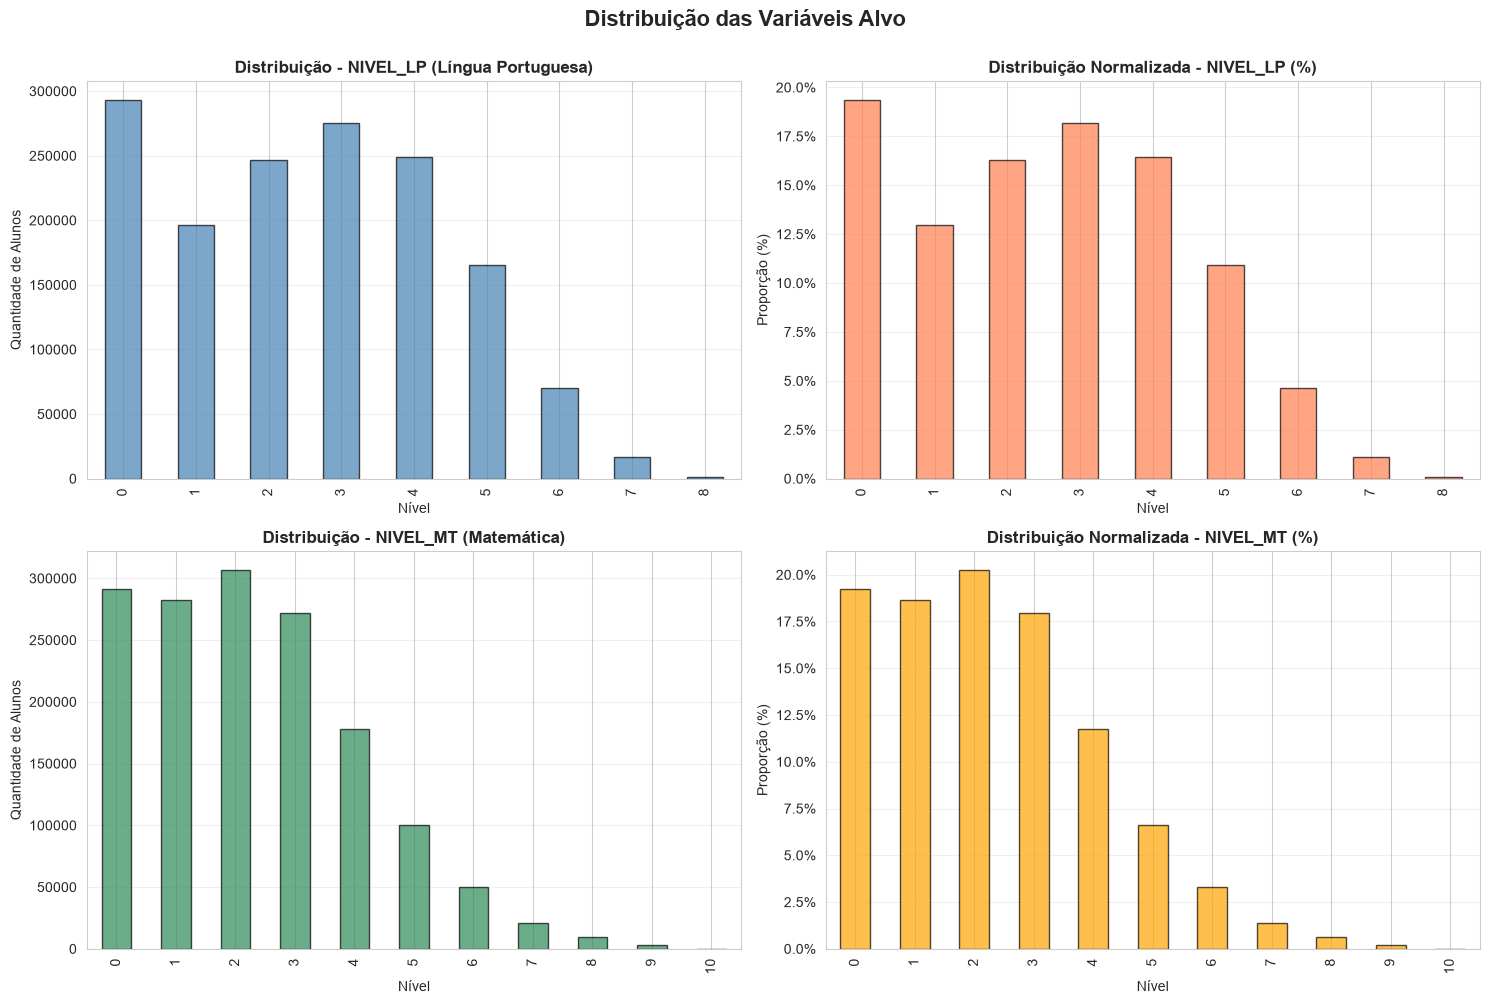

In [119]:
# Configurar estilo do seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Criar subplots para as distribuições das variáveis alvo
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribuição das Variáveis Alvo', fontsize=16, fontweight='bold', y=1.00)

if 'NIVEL_LP' in df_final.columns:
    # Histograma - NIVEL_LP
    ax1 = axes[0, 0]
    df_final['NIVEL_LP'].value_counts().sort_index().plot(
        kind='bar', ax=ax1, color='steelblue', edgecolor='black', alpha=0.7
    )
    ax1.set_title('Distribuição - NIVEL_LP (Língua Portuguesa)', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Nível')
    ax1.set_ylabel('Quantidade de Alunos')
    ax1.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_LP
    ax2 = axes[0, 1]
    df_final['NIVEL_LP'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax2, color='coral', edgecolor='black', alpha=0.7
    )
    ax2.set_title('Distribuição Normalizada - NIVEL_LP (%)', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Nível')
    ax2.set_ylabel('Proporção (%)')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax2.grid(axis='y', alpha=0.3)

if 'NIVEL_MT' in df_final.columns:
    # Histograma - NIVEL_MT
    ax3 = axes[1, 0]
    df_final['NIVEL_MT'].value_counts().sort_index().plot(
        kind='bar', ax=ax3, color='seagreen', edgecolor='black', alpha=0.7
    )
    ax3.set_title('Distribuição - NIVEL_MT (Matemática)', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Nível')
    ax3.set_ylabel('Quantidade de Alunos')
    ax3.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_MT
    ax4 = axes[1, 1]
    df_final['NIVEL_MT'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax4, color='orange', edgecolor='black', alpha=0.7
    )
    ax4.set_title('Distribuição Normalizada - NIVEL_MT (%)', fontweight='bold', fontsize=12)
    ax4.set_xlabel('Nível')
    ax4.set_ylabel('Proporção (%)')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


*Análise de correlações*

Vamos examinar as correlações entre as features numéricas e as variáveis alvo.

In [120]:
print("\n" + "=" * 80)
print("ANÁLISE DE CORRELAÇÕES")
print("=" * 80)

# Calcular correlações para variáveis numéricas
numeric_cols_all = df_final.select_dtypes(include=[np.number]).columns.tolist()

# Calcular matriz de correlação
corr_matrix = df_final[numeric_cols_all].corr()

# Correlações com NIVEL_LP
if 'NIVEL_LP' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_LP:")
    corr_lp = corr_matrix['NIVEL_LP'].drop('NIVEL_LP').sort_values(ascending=False)
    corr_lp = corr_lp[corr_lp.index != 'NIVEL_MT']  # Remover correlação com MT
    corr_lp = corr_lp[~corr_lp.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_lp.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlações com NIVEL_MT
if 'NIVEL_MT' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_MT:")
    corr_mt = corr_matrix['NIVEL_MT'].drop('NIVEL_MT').sort_values(ascending=False)
    corr_mt = corr_mt[corr_mt.index != 'NIVEL_LP']  # Remover correlação com LP
    corr_mt = corr_mt[~corr_mt.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_mt.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlação entre as variáveis alvo
if 'NIVEL_LP' in corr_matrix.columns and 'NIVEL_MT' in corr_matrix.columns:
    corr_lp_mt = corr_matrix.loc['NIVEL_LP', 'NIVEL_MT']
    print(f"\n◉ Correlação entre NIVEL_LP e NIVEL_MT: {corr_lp_mt:.4f}")
    if corr_lp_mt > 0.7:
        print("   -  Correlação forte: os níveis de proficiência em LP e MT estão altamente relacionados")
    elif corr_lp_mt > 0.3:
        print("   -  Correlação moderada: existe relação entre LP e MT")
    else:
        print("   -  Correlação fraca: LP e MT são relativamente independentes")



ANÁLISE DE CORRELAÇÕES

◉ Top 10 Features com maior Correlação com NIVEL_LP:
   Feature                          Correlação
   ---------------------------------------------
    1. MEDIA_EM_NIVEL_LP                 0.3785
    2. MEDIA_EM_NIVEL_MT                 0.3421
    3. TX_RESP_Q11b                      0.1093
    4. TX_Q035                           0.1019
    5. TX_RESP_Q11a                      0.0983
    6. PC_FORMACAO_DOCENTE_MEDIO         0.0920
    7. TX_Q108                           0.0848
    8. TX_RESP_Q07a                      0.0847
    9. TX_Q119                           0.0661
   10. TX_Q036                           0.0653

◉ Top 10 Features com maior Correlação com NIVEL_MT:
   Feature                          Correlação
   ---------------------------------------------
    1. MEDIA_EM_NIVEL_MT                 0.3931
    2. MEDIA_EM_NIVEL_LP                 0.3554
    3. TX_Q035                           0.0978
    4. TX_Q108                           0.0857
    

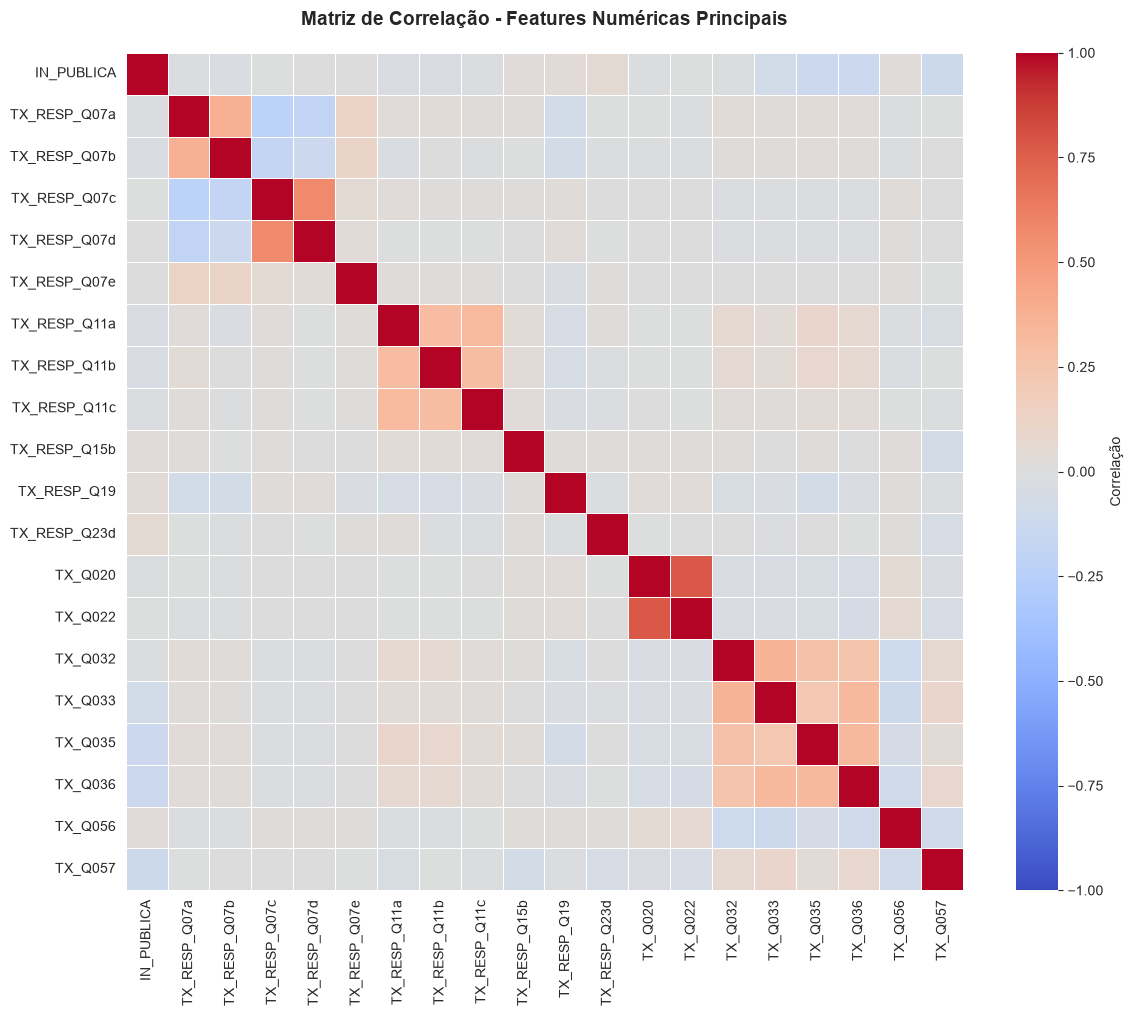

In [121]:
# Visualizar matriz de correlação (primeiras features)
if 'NIVEL_LP' in df_final.columns or 'NIVEL_MT' in df_final.columns:
    # Selecionar apenas as colunas numéricas relevantes (não IDs)
    cols_para_corr = [col for col in numeric_cols_all if not col.startswith('ID_')][:20]
    
    plt.figure(figsize=(12, 10))
    corr_subset = df_final[cols_para_corr].corr()
    
    sns.heatmap(
        corr_subset,
        annot=False,
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Correlação'},
        vmin=-1, vmax=1
    )
    
    plt.title('Matriz de Correlação - Features Numéricas Principais', fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

*Principais características do dataset*

In [122]:
print("\n" + "=" * 80)
print("RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA")
print("=" * 80)

# Resumo geral
print("\n◉ DATASET SUMMARY:")
print(f"   • Total de amostras: {len(df_final):,}")
print(f"   • Total de features: {len(df_final.columns)}")
print(f"   • Features numéricas: {len(numeric_cols_all)}")
print(f"   • Features categóricas: {len(categorical_cols)}")

# Avaliar completude dos dados
missing_percentage = (df_final.isnull().sum().sum() / (len(df_final) * len(df_final.columns))) * 100
print("\n◉ QUALIDADE DOS DADOS:")
print(f"   • Completude geral: {100 - missing_percentage:.2f}%")
print(f"   • Dados ausentes: {missing_percentage:.2f}%")

if missing_percentage < 5:
    print("   ✓ Qualidade Excelente! Menos de 5% de dados ausentes")
elif missing_percentage < 20:
    print("   !  Qualidade Boa. Será necessário imputação de dados")
else:
    print("   !  Atenção: Significativa quantidade de dados ausentes")

# Análise das variáveis alvo
print("\n◉ VARIÁVEIS ALVO:")
if 'NIVEL_LP' in df_final.columns:
    unique_lp = df_final['NIVEL_LP'].nunique()
    print(f"   • NIVEL_LP: {unique_lp} classes (Nível 0-8)")
    
    # Verificar balanceamento
    lp_counts = df_final['NIVEL_LP'].value_counts()
    lp_ratio = lp_counts.max() / lp_counts.min()
    if lp_ratio < 3:
        print(f"      ✓ Balanceamento: Bom (proporção máx/min = {lp_ratio:.2f})")
    elif lp_ratio < 10:
        print(f"      !  Balanceamento: Moderado (proporção máx/min = {lp_ratio:.2f})")
    else:
        print(f"      !  Balanceamento: Desbalanceado (proporção máx/min = {lp_ratio:.2f})")

if 'NIVEL_MT' in df_final.columns:
    unique_mt = df_final['NIVEL_MT'].nunique()
    print(f"   • NIVEL_MT: {unique_mt} classes (Nível 0-10)")
    
    # Verificar balanceamento
    mt_counts = df_final['NIVEL_MT'].value_counts()
    mt_ratio = mt_counts.max() / mt_counts.min()
    if mt_ratio < 3:
        print(f"      ✓ Balanceamento: Bom (proporção máx/min = {mt_ratio:.2f})")
    elif mt_ratio < 10:
        print(f"      !  Balanceamento: Moderado (proporção máx/min = {mt_ratio:.2f})")
    else:
        print(f"      !  Balanceamento: Desbalanceado (proporção máx/min = {mt_ratio:.2f})")



RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA

◉ DATASET SUMMARY:
   • Total de amostras: 1,514,448
   • Total de features: 80
   • Features numéricas: 52
   • Features categóricas: 28

◉ QUALIDADE DOS DADOS:
   • Completude geral: 89.70%
   • Dados ausentes: 10.30%
   !  Qualidade Boa. Será necessário imputação de dados

◉ VARIÁVEIS ALVO:
   • NIVEL_LP: 9 classes (Nível 0-8)
      !  Balanceamento: Desbalanceado (proporção máx/min = 244.23)
   • NIVEL_MT: 11 classes (Nível 0-10)
      !  Balanceamento: Desbalanceado (proporção máx/min = 3880.11)


*Preenchimento dos valores nulos do dataset final*

Após a análise exploratória de dados, percebe-se que existem uma quantidade de valores ausentes considerável para o dataset. Realizamos, portanto, o tratamento de valores ausentes no conjunto de dados utilizando estratégias diferentes conforme o tipo de variável. Para variáveis numéricas (como médias de proficiência e medidas contínuas), foi aplicada a imputação pela mediana, geralmente agrupada por UF ou município. Já para variáveis categóricas (como características do aluno, família e infraestrutura escolar), foi utilizada a moda, também segmentada por UF, município ou escola quando apropriado, preservando padrões regionais e contextuais dos dados ao máximo. Após a etapa de imputação, as linhas que ainda continham valores ausentes foram removidas com dropna, garantindo a integridade final do dataset. 

In [123]:
# Verificando a quantidade de dados ausentes
print("\n◉ Dimensões do Dataset:")
print(f"   Linhas (amostras): {df_final.shape[0]:,}")

print("\n◉ Valores Ausentes (Missing Values):")
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final)) * 100
missing_df = pd.DataFrame({
    'Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Ausentes', ascending=False)
missing_df = missing_df[missing_df['Ausentes'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("  ✓ Nenhum valor ausente detectado!")


◉ Dimensões do Dataset:
   Linhas (amostras): 1,514,448

◉ Valores Ausentes (Missing Values):
                           Ausentes  Percentual (%)
TX_RESP_Q09                  404299       26.696130
TX_RESP_Q07d                 396942       26.210342
TX_RESP_Q07c                 367739       24.282049
MEDIA_EM_NIVEL_MT            331568       21.893654
MEDIA_EM_NIVEL_LP            331568       21.893654
TX_Q022                      290322       19.170153
TX_Q087                      289785       19.134695
TX_Q035                      288749       19.066287
TX_Q020                      288545       19.052817
TX_Q082                      288220       19.031357
TX_Q208                      287874       19.008510
TX_Q079                      286518       18.918972
TX_Q083                      286468       18.915671
TX_Q085                      286370       18.909200
TX_Q078                      286160       18.895333
TX_Q033                      285186       18.831020
TX_Q036              

In [124]:
# Preenchendo MEDIA_EM_NIVEL_MT - média de proficiência em Matemática do EM (escala SAEB) por escola - 21.89% faltando -> mediana por UF
df_final['MEDIA_EM_NIVEL_MT'] = df_final.groupby('ID_UF')['MEDIA_EM_NIVEL_MT'].transform(
    lambda x: x.fillna(x.median())
)

# Preenchendo MEDIA_EM_NIVEL_LP - média de proficiência em Língua Portuguesa do EM (escala SAEB) por escola - 21.89% faltando -> mediana por UF
df_final['MEDIA_EM_NIVEL_LP'] = df_final.groupby('ID_UF')['MEDIA_EM_NIVEL_LP'].transform(
    lambda x: x.fillna(x.median())
)

# Preenchendo TX_RESP_Q01 - sexo do aluno - 1.07% faltando -> moda por UF
df_final['TX_RESP_Q01'] = df_final.groupby('ID_UF')['TX_RESP_Q01'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchando TX_RESP_Q02 - idade do aluno - 3.07% faltando -> moda por UF
df_final['TX_RESP_Q02'] = df_final.groupby('ID_UF')['TX_RESP_Q02'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q03 - língua falada pelos pais em casa - 1.22% faltando -> moda por UF
df_final['TX_RESP_Q03'] = df_final.groupby('ID_UF')['TX_RESP_Q03'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q04 - cor ou raça do aluno - 2.63% faltando -> moda por UF
df_final['TX_RESP_Q04'] = df_final.groupby('ID_UF')['TX_RESP_Q04'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q05a - possui deficiência - 2.36% faltando -> moda geral
df_final['TX_RESP_Q05a'] = df_final['TX_RESP_Q05a'].fillna(df_final['TX_RESP_Q05a'].mode().iloc[0])

# Preenchendo TX_RESP_Q05b - possui transtorno do espectro autista - 4.00% faltando -> moda geral
df_final['TX_RESP_Q05b'] = df_final['TX_RESP_Q05b'].fillna(df_final['TX_RESP_Q05b'].mode().iloc[0])

# Preenchendo TX_RESP_Q05c - possui altas habilidades ou superdotação - 4.41% faltando -> moda geral
df_final['TX_RESP_Q05c'] = df_final['TX_RESP_Q05c'].fillna(df_final['TX_RESP_Q05c'].mode().iloc[0])

# Preenchendo TX_RESP_Q06 - número de pessoas que moram na casa do aluno - 2.23% faltando -> moda por UF
df_final['TX_RESP_Q06'] = df_final.groupby('ID_UF')['TX_RESP_Q06'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q07a - mora com mãe(s) ou madrasta(s) - 5.96% faltando -> moda por UF
df_final['TX_RESP_Q07a'] = df_final.groupby('ID_UF')['TX_RESP_Q07a'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q07b - mora com pai(s) ou padrasto(s) - 10.02% faltando -> moda por UF
df_final['TX_RESP_Q07b'] = df_final.groupby('ID_UF')['TX_RESP_Q07b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q07c - mora com avó(s) - 24.28% faltando -> moda por UF
df_final['TX_RESP_Q07c'] = df_final.groupby('ID_UF')['TX_RESP_Q07c'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q07d - mora com avô(s) - 26.21% faltando -> moda por UF
df_final['TX_RESP_Q07d'] = df_final.groupby('ID_UF')['TX_RESP_Q07d'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q07e - mora com outros familiares (irmãos, tios, primos etc.) - 10.82% faltando -> moda por UF
df_final['TX_RESP_Q07e'] = df_final.groupby('ID_UF')['TX_RESP_Q07e'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q08 - maior escolaridade da mãe/responsável feminina - 14.57% faltando -> moda por município
df_final['TX_RESP_Q08'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q08'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q09 - maior escolaridade do pai/responsável masculino - 26.70% faltando -> moda por municipio
df_final['TX_RESP_Q09'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q09'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10a - frequência com que pais leem em casa - 2.09% faltando -> moda por UF
df_final['TX_RESP_Q10a'] = df_final.groupby('ID_UF')['TX_RESP_Q10a'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10b - frequência com que pais conversam sobre o que ocorre na escola - 2.23% faltando -> moda por UF
df_final['TX_RESP_Q10b'] = df_final.groupby('ID_UF')['TX_RESP_Q10b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10c - frequência com que pais incentivam o aluno a estudar - 2.25% faltando -> moda por UF
df_final['TX_RESP_Q10c'] = df_final.groupby('ID_UF')['TX_RESP_Q10c'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10d - frequência com que pais incentivam a fazer tarefa de casa - 2.52% faltando -> moda por UF
df_final['TX_RESP_Q10d'] = df_final.groupby('ID_UF')['TX_RESP_Q10d'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10e - frequência com que pais incentivam a comparecer às aulas - 2.62% faltando -> moda por UF
df_final['TX_RESP_Q10e'] = df_final.groupby('ID_UF')['TX_RESP_Q10e'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10f - frequência com que pais vão às reuniões de pais - 2.12% faltando -> moda por UF
df_final['TX_RESP_Q10f'] = df_final.groupby('ID_UF')['TX_RESP_Q10f'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q11a - rua do aluno tem asfalto ou calçamento - 1.29% faltando -> moda por município
df_final['TX_RESP_Q11a'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q11a'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q11b - rua do aluno tem água tratada - 2.17% faltando -> moda por município
df_final['TX_RESP_Q11b'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q11b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q11c - rua do aluno tem iluminação - 1.97% faltando -> moda por município
df_final['TX_RESP_Q11c'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q11c'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q12b - quantidade de computadores/notebooks em casa - 7.99% faltando -> moda por UF
df_final['TX_RESP_Q12b'] = df_final.groupby('ID_UF')['TX_RESP_Q12b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q12c - quantidade de quartos para dormir em casa - 6.40% faltando -> moda por UF
df_final['TX_RESP_Q12c'] = df_final.groupby('ID_UF')['TX_RESP_Q12c'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q14 - tempo de deslocamento até a escola - 7.12% faltando -> moda por município
df_final['TX_RESP_Q14'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q14'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q15b - utiliza passe escolar para ir à escola - 10.07% faltando -> moda por município
df_final['TX_RESP_Q15b'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q15b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q16 - forma habitual de chegar à escola - 14.93% faltando -> moda por município
df_final['TX_RESP_Q16'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q16'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q17 - idade de entrada na escola - 5.34% faltando -> moda por UF
df_final['TX_RESP_Q17'] = df_final.groupby('ID_UF')['TX_RESP_Q17'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q18 - tipo de escola frequentada desde o 1º ano do EF - 5.29% faltando -> moda por UF
df_final['TX_RESP_Q18'] = df_final.groupby('ID_UF')['TX_RESP_Q18'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q19 - já foi reprovado(a) - 5.28% faltando -> moda por UF
df_final['TX_RESP_Q19'] = df_final.groupby('ID_UF')['TX_RESP_Q19'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)   
# Preenchendo TX_RESP_Q21a - tempo fora da escola para estudar/lição de casa - 5.30% faltando -> moda por UF
df_final['TX_RESP_Q21a'] = df_final.groupby('ID_UF')['TX_RESP_Q21a'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q21b - tempo fora da escola para atividades extracurriculares - 6.77% faltando -> moda por UF
df_final['TX_RESP_Q21b'] = df_final.groupby('ID_UF')['TX_RESP_Q21b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q21c - tempo fora da escola para trabalhar em casa - 6.06% faltando -> moda por UF
df_final['TX_RESP_Q21c'] = df_final.groupby('ID_UF')['TX_RESP_Q21c'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q21d - tempo fora da escola para trabalhar fora de casa - 6.09% faltando -> moda por UF
df_final['TX_RESP_Q21d'] = df_final.groupby('ID_UF')['TX_RESP_Q21d'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q21e - tempo fora da escola para lazer (TV, internet, música etc.) - 5.53% faltando -> moda por UF
df_final['TX_RESP_Q21e'] = df_final.groupby('ID_UF')['TX_RESP_Q21e'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)  

# Preenchendo TX_RESP_Q23d - sente-se seguro(a) na escola - 2.80% faltando -> moda por escola
df_final['TX_RESP_Q23d'] = df_final.groupby('ID_ESCOLA')['TX_RESP_Q23d'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q24 - pretensão ao terminar o ensino médio - 2.30% faltando -> moda por UF
df_final['TX_RESP_Q24'] = df_final.groupby('ID_UF')['TX_RESP_Q24'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q020 - horas semanais dedicadas pelo diretor a liderar equipes de trabalho(19,05% faltando) -> mediana por município
df_final['TX_Q020'] = df_final.groupby('ID_MUNICIPIO')['TX_Q020'].transform(
    lambda x: x.fillna(x.median())
)

# Preenchendo TX_Q022 - horas semanais dedicadas pelo diretor ao atendimento da comunidade escolar(19,17% faltando) -> mediana por município
df_final['TX_Q022'] = df_final.groupby('ID_MUNICIPIO')['TX_Q022'].transform(
    lambda x: x.fillna(x.median())
)

# Preenchendo TX_Q032 - condição de uso das televisões da escola(18,81% faltando) -> moda por município
df_final['TX_Q032'] = df_final.groupby('ID_MUNICIPIO')['TX_Q032'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q033 - condição de uso dos projetores multimídia (datashow)(18,83% faltando) -> moda por município
df_final['TX_Q033'] = df_final.groupby('ID_MUNICIPIO')['TX_Q033'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q035 - condição de uso dos softwares educacionais(19,07% faltando) -> moda por município
df_final['TX_Q035'] = df_final.groupby('ID_MUNICIPIO')['TX_Q035'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q036 - condição de uso da internet banda larga(18,83% faltando) -> moda por município
df_final['TX_Q036'] = df_final.groupby('ID_MUNICIPIO')['TX_Q036'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q056 - houve atraso no repasse de recursos financeiros para pagamento de pessoal(18,60% faltando) -> moda por município
df_final['TX_Q056'] = df_final.groupby('ID_MUNICIPIO')['TX_Q056'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q057 - o quadro de professores da escola estava completo(18,15% faltando) -> moda por município
df_final['TX_Q057'] = df_final.groupby('ID_MUNICIPIO')['TX_Q057'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q078 - calendário escolar interrompido por falta de água(18,90% faltando) -> moda por município
df_final['TX_Q078'] = df_final.groupby('ID_MUNICIPIO')['TX_Q078'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q079 - calendário escolar interrompido por falta de energia elétrica(18,92% faltando) -> moda por município
df_final['TX_Q079'] = df_final.groupby('ID_MUNICIPIO')['TX_Q079'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q081 - calendário escolar interrompido por greve de professores(18,52% faltando) -> moda por município
df_final['TX_Q081'] = df_final.groupby('ID_MUNICIPIO')['TX_Q081'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q082 - calendário escolar interrompido por episódios de violência(19,03% faltando) -> moda por município
df_final['TX_Q082'] = df_final.groupby('ID_MUNICIPIO')['TX_Q082'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q083 - calendário escolar interrompido por problemas de infraestrutura predial (18,92% faltando) -> moda por município
df_final['TX_Q083'] = df_final.groupby('ID_MUNICIPIO')['TX_Q083'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q085 - calendário escolar interrompido por eventos climáticos(18,91% faltando) -> moda por município
df_final['TX_Q085'] = df_final.groupby('ID_MUNICIPIO')['TX_Q085'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q087 - calendário escolar interrompido por problemas de saúde pública(19,13% faltando) -> moda por município
df_final['TX_Q087'] = df_final.groupby('ID_MUNICIPIO')['TX_Q087'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q108 - condição de uso dos equipamentos da área externa de recreação(18,12% faltando) -> moda por município
df_final['TX_Q108'] = df_final.groupby('ID_MUNICIPIO')['TX_Q108'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q119 - escola é militar ou militarizada(18,37% faltando) -> moda por município
df_final['TX_Q119'] = df_final.groupby('ID_MUNICIPIO')['TX_Q119'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q129 - escola recebe recursos federais como fonte de financiamento(18,29% faltando) -> moda por município
df_final['TX_Q129'] = df_final.groupby('ID_MUNICIPIO')['TX_Q129'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q130 - escola recebe recursos estaduais ou municipais como fonte de financiamento(18,54% faltando) -> moda por município
df_final['TX_Q130'] = df_final.groupby('ID_MUNICIPIO')['TX_Q130'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q139 - escola oferece merenda aos estudantes(18,49% faltando) -> moda por município
df_final['TX_Q139'] = df_final.groupby('ID_MUNICIPIO')['TX_Q139'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q191 - eficácia do contato com familiares para reduzir abandono escolar(18,48% faltando) -> moda por município
df_final['TX_Q191'] = df_final.groupby('ID_MUNICIPIO')['TX_Q191'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q194 - escola possui projetos de ciência e tecnologia(18,50% faltando) -> moda por município
df_final['TX_Q194'] = df_final.groupby('ID_MUNICIPIO')['TX_Q194'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q203 - escola possui projetos sobre uso de drogas(18,32% faltando) -> moda por município
df_final['TX_Q203'] = df_final.groupby('ID_MUNICIPIO')['TX_Q203'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q205 - escola realiza preparação para avaliações externas(18,32% faltando) -> moda por município
df_final['TX_Q205'] = df_final.groupby('ID_MUNICIPIO')['TX_Q205'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q206 - escola inscreve alunos em olimpíadas de conhecimento(18,36% faltando) -> moda por município
df_final['TX_Q206'] = df_final.groupby('ID_MUNICIPIO')['TX_Q206'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q207 - escola realiza feira de ciências(18,57% faltando) -> moda por município
df_final['TX_Q207'] = df_final.groupby('ID_MUNICIPIO')['TX_Q207'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q208 - escola realiza feira de artes(19,01% faltando) -> moda por município
df_final['TX_Q208'] = df_final.groupby('ID_MUNICIPIO')['TX_Q208'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q209 - escola realiza campeonatos esportivos (18,37% faltando) -> moda por município
df_final['TX_Q209'] = df_final.groupby('ID_MUNICIPIO')['TX_Q209'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Eliminando linhas que possuem pelo menos um valor ausente após preenchimento
df_final = df_final.dropna(axis=0, how='any')

# Verificando a quantidade de dados ausentes após o preenchimento
print("\n◉ Dimensões do Dataset:")
print(f"   Linhas (amostras): {df_final.shape[0]:,}")
print("\n◉ Valores Ausentes (Missing Values):")
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final)) * 100
missing_df = pd.DataFrame({
    'Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Ausentes', ascending=False)
missing_df = missing_df[missing_df['Ausentes'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("  ✓ Nenhum valor ausente detectado!")



◉ Dimensões do Dataset:
   Linhas (amostras): 1,428,294

◉ Valores Ausentes (Missing Values):
  ✓ Nenhum valor ausente detectado!


# Treinamento dos modelos

### Modelo 1

##### Construção e treinamento

##### Avaliação e métricas

### Modelo 2

##### Construção e treinamento

##### Avaliação e métricas

### Modelo 3

##### Construção e treinamento

##### Avaliação e métricas

### Modelo 4

##### Construção e treinamento

##### Avaliação e métricas

# Validação e teste

# Ajuste de hiperparâmetros

# Conclusão